In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [4]:
# Load clean dataset
df = pd.read_csv('hotel_bookings_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (86639, 42)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,arrival_date_month_num,arrival_date,total_nights,total_guests,total_revenue,season,lead_time_bucket,traveler_type,has_special_requests,includes_weekend
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Last-minute (1-7d),Leisure,0,0
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Short (8-30d),Corporate,0,0
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,196.0,Summer,Short (8-30d),Leisure,1,0
3,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,214.0,Summer,Same-day,Leisure,0,0
4,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,206.0,Summer,Short (8-30d),Leisure,1,0


In [5]:
# Select features for segmentation
seg_features = [
    'lead_time', 'adr', 'total_nights', 'total_guests',
    'total_revenue', 'total_of_special_requests',
    'booking_changes', 'previous_cancellations',
    'required_car_parking_spaces', 'is_repeated_guest'
]

df_seg = df[seg_features].copy()
print(f'Segmentation dataset shape: {df_seg.shape}')

Segmentation dataset shape: (86639, 10)


In [6]:
# Scale features — KMeans is distance-based so scaling is essential
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_seg)
print('Scaling done.')

Scaling done.


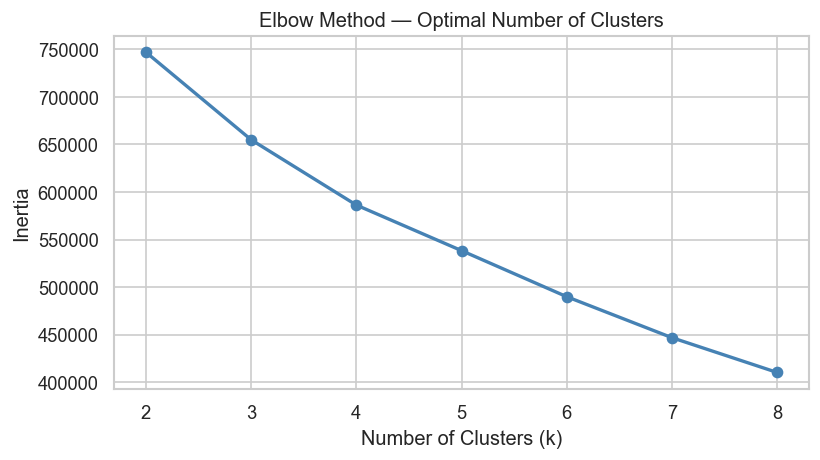

In [8]:
# Elbow Method — find optimal number of clusters
inertia = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('04_elbow_curve.png', bbox_inches='tight')
plt.show()

In [9]:
# Fit KMeans with k=4 (based on elbow)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

print('Cluster distribution:')
print(df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     3124
1    55499
2     6549
3    21467
Name: count, dtype: int64


In [10]:
# Cluster profiles — mean values per cluster
profile = df.groupby('cluster')[seg_features + ['is_canceled']].mean().round(2)
profile

,lead_time,adr,total_nights,total_guests,total_revenue,total_of_special_requests,booking_changes,previous_cancellations,required_car_parking_spaces,is_repeated_guest,is_canceled
cluster,,,,,,,,,,,
0,17.93,68.68,2.00,1.37,150.18,0.70,0.29,0.50,0.19,1.0,0.08
1,67.22,93.24,2.81,1.87,247.37,0.59,0.21,0.01,0.00,0.0,0.28
2,56.18,112.80,3.11,2.16,366.70,0.82,0.38,0.01,1.01,0.0,0.00
3,130.53,143.32,6.23,2.51,815.13,0.95,0.37,0.01,0.01,0.0,0.38


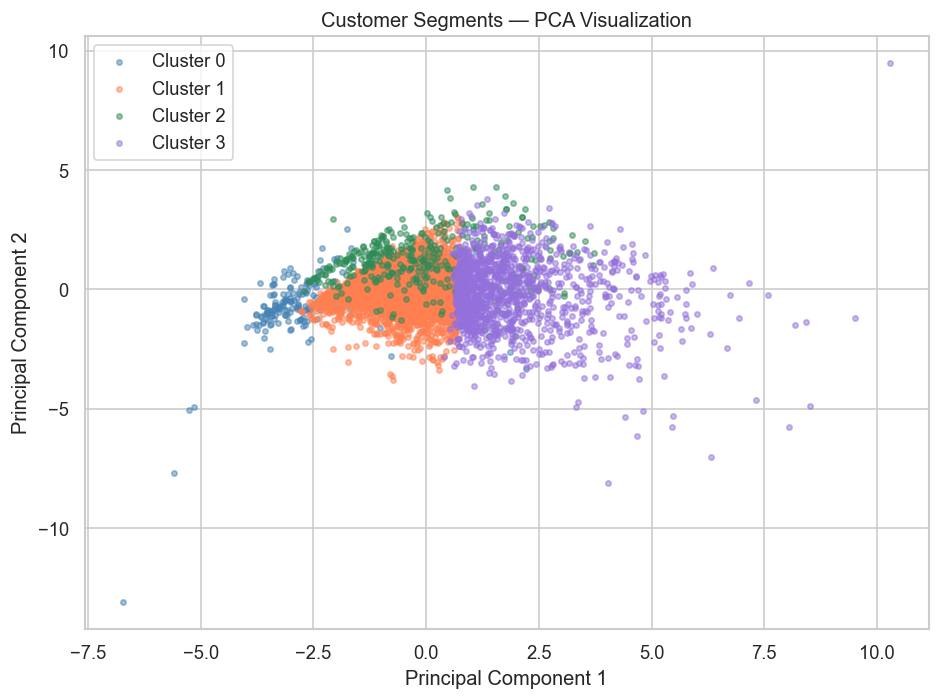

In [11]:
# Visualize clusters using PCA (reduce to 2D)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].values

# Sample 5000 points for plot clarity
sample = df_pca.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
for i in range(k):
    pts = sample[sample['cluster'] == i]
    ax.scatter(pts['PC1'], pts['PC2'], s=10, alpha=0.5, color=colors[i], label=f'Cluster {i}')
ax.set_title('Customer Segments — PCA Visualization')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend()
plt.tight_layout()
plt.savefig('05_cluster_pca.png', bbox_inches='tight')
plt.show()

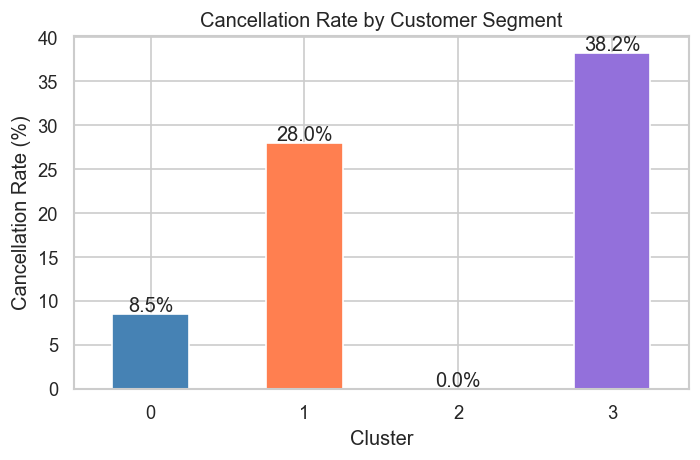

In [12]:
# Cancellation rate per cluster
cancel_cluster = df.groupby('cluster')['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
cancel_cluster.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=0)
ax.set_title('Cancellation Rate by Customer Segment')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Cluster')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.3), ha='center')
plt.tight_layout()
plt.savefig('06_cancel_by_cluster.png', bbox_inches='tight')
plt.show()

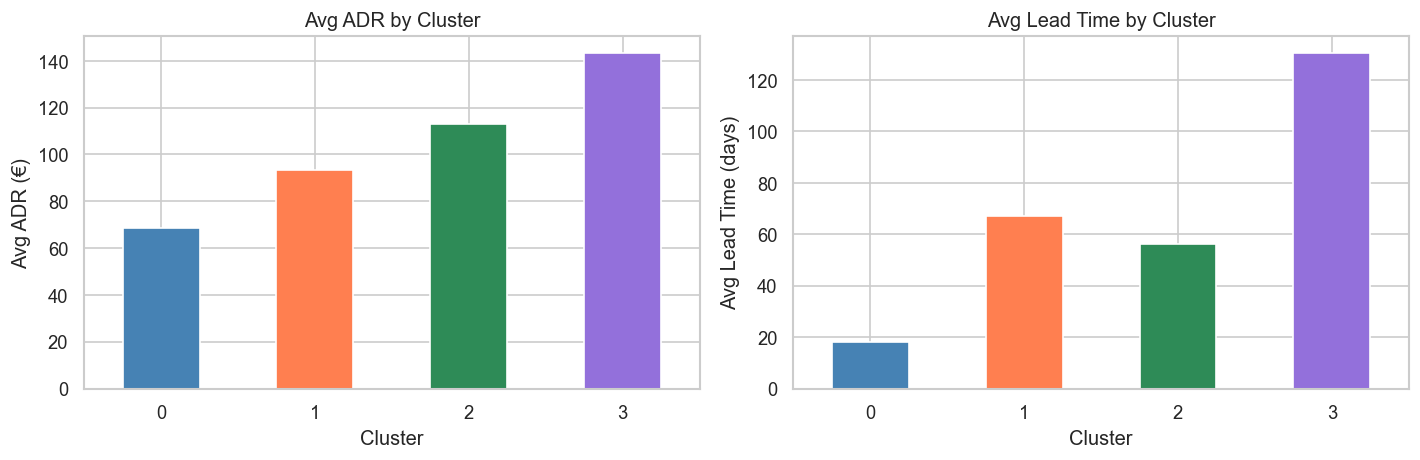

In [13]:
# ADR and Lead Time by cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('cluster')['adr'].mean().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Avg ADR by Cluster')
axes[0].set_ylabel('Avg ADR (€)')
axes[0].set_xlabel('Cluster')

df.groupby('cluster')['lead_time'].mean().plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=0)
axes[1].set_title('Avg Lead Time by Cluster')
axes[1].set_ylabel('Avg Lead Time (days)')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('07_adr_leadtime_by_cluster.png', bbox_inches='tight')
plt.show()

In [14]:
# Segment label mapping based on profiles
segment_labels = {
    0: 'Budget Short-Stay',
    1: 'Premium Long-Stay',
    2: 'Last-Minute Leisure',
    3: 'Early Planner Corporate'
}
df['segment_label'] = df['cluster'].map(segment_labels)
print('Segment distribution:')
print(df['segment_label'].value_counts())

Segment distribution:
segment_label
Premium Long-Stay          55499
Early Planner Corporate    21467
Last-Minute Leisure         6549
Budget Short-Stay           3124
Name: count, dtype: int64


In [15]:
# Export segmented dataset
df.to_csv('customer_segments.csv', index=False)
print('Saved:customer_segments.csv')

Saved:customer_segments.csv
